# MCR-ALS example (adapted from Jaumot et al. 2005)

In this example, we perform the MCR ALS optimization of a dataset
corresponding to a HPLC-DAD run, from @jaumot:2005 and @jaumot:2015.

This dataset (and others) can be downloaded from the [Multivariate Curve
Resolution
Homepage](https://mcrals.wordpress.com/download/example-data-sets).

For the user convenience, this dataset is present in the test data
directory [scp.preferences.datadir]{.title-ref} of SpectroChemPy as
`als2004dataset.MAT`.


Import the spectrochempy API package


In [1]:
import spectrochempy as scp

"<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAABgAAAAYCAYAAADgdz34AAAAAXNSR0IArs4c6QAAAAlw SFlzAAAJOgAACToB8GSSSgAAAetpVFh0WE1MOmNvbS5hZG9iZS54bXAAAAAAADx4OnhtcG1ldGEgeG1sbnM6eD0iYWRvYmU6bnM6 bWV0YS8iIHg6eG1wdGs9IlhNUCBDb3JlIDUuNC4wIj4KICAgPHJkZjpSREYgeG1sbnM6cmRmPSJodHRwOi8vd3d3LnczLm9yZy8x OTk5LzAyLzIyLXJkZi1zeW50YXgtbnMjIj4KICAgICAgPHJkZjpEZXNjcmlwdGlvbiByZGY6YWJvdXQ9IiIKICAgICAgICAgICAg eG1sbnM6eG1wPSJodHRwOi8vbnMuYWRvYmUuY29tL3hhcC8xLjAvIgogICAgICAgICAgICB4bWxuczp0aWZmPSJodHRwOi8vbnMu YWRvYmUuY29tL3RpZmYvMS4wLyI+CiAgICAgICAgIDx4bXA6Q3JlYXRvclRvb2w+bWF0cGxvdGxpYiB2ZXJzaW9uIDIuMS4wLCBo dHRwOi8vbWF0cGxvdGxpYi5vcmcvPC94bXA6Q3JlYXRvclRvb2w+CiAgICAgICAgIDx0aWZmOk9yaWVudGF0aW9uPjE8L3RpZmY6 T3JpZW50YXRpb24+CiAgICAgIDwvcmRmOkRlc2NyaXB0aW9uPgogICA8L3JkZjpSREY+CjwveDp4bXBtZXRhPgqNQaNYAAAGiUlE QVRIDY1We4xU1Rn/3XPuYx47u8w+hnU38hTcuoUEt/6D2y4RB0ME1BoEd9taJaKh9CFiN7YGp7appUAMNmktMZFoJTYVLVQ0smsy 26CN0SU1QgsuFAaW3WVmx33N677O6XfuyoIxTXqSO/fec+75fd93vt/3/UbDV0aKSZmCpkFMLz3T9utuu2N+o98aDSMBKVAo89z5 y+zEz3ZafcCOfvWdlGCalqKn1Bf71CygTd+mf1esSOnpdMpTb+vWpTZuWVfe3jLPa5tzHYNm0T5N0gpdkkHaDBeGBU6d1/t/fyS8 +/CbqdfUvmsx1PuMgc2bNxv79u1zgd31r+7JH1jbIZKxWRXAcYUQ8IWvBfBXNjEuJWPgMA02NR7C3/pYT9fjdZ3A9tGrWF8YSJHn qcDz3y7q2T967PZv+gnYJdd1mEZ+62zGDQV/dQgKhmLzDNOXCEWM3j6eTT5Y3w78dOBKJLR1PQf+4ivPj76UPZnssBN+wbM9Aet/ AV81Mf1EEULXYfOobvX2WWQk0aoioXwwSmirOlioY0mu8BIouzYl7P8GV3vpqCCEZvlFz769w08oLDWvyKIyL1asSm28d6WfzA97 ztvvV1kexUMsmhlkULEkuGYmFYC6AvfUrITnwUKl5K79lkjeSSRRTCTbQPd95e1WzMbZSya74XoXAxctCllCnbECMOjZNGRwvzIX nD85wbkMmKK+U045Dtdi8Qp+SAxU2GTg2bYlC9224pgvmSb54vkVTBQYyhUt2KjAMyMmPjwRQW5Mh2WKwJhlBh6jVGagFM84wZnQ 4bpC0Rt4pk1PbSt0NDcxDA5xryosDHWgtbM0DGZDWLSoiDMDYeQnGVrmOThxLozB0RAaahzkJzjKNqcIQBymJFMkOlN8Dqjpg0XY Tx5xO/QbmmUrqIjGJznq47TqTaClKYfjp+PInLMwnOdYvtQBZ2XcunQY+VwIo4U4muoFEjVEFE6lQyEUKzHYfgQG9ylCyngU+Cxj tOqxCDGHcCsOMCs6iQul5ZiStdATYxjMZXDLTUVwLY8Jey4uOh2IxjwsrP8UXJYxUrkZrghBahzV5iXU6gNkq0Z1EzIsUBUSCV2n EOHo0LVxHCpuxabJJdhi5PFnvw5vLXwXIfNZvD/+JNo/X40NegE54sUaazl+UL8XD1x+FB9Ijjt4EQfdGN6J/x131LwIV9ap/AYs 0x1fz1ZKFbh6A7qKy/By9Dg6G36Ep91vUJJ15Cqr0Z67E8/HzmBrw1OwxWyM+3Mo6BAuSB17oyfx0Oyl2DN0Hqs/70Cx6hBCvESF UY1ShWXZZEE7OTAYxZzaPH4TuoiusZvRnunFy2NbiHYuBp2vB66srX4vMEjpRKPxKXmnoQ4+Mn4DPiv8CYcrs3GfNUXJLtM+alSO hrMj/KT+wBNW3+E/2liywNO3iSflbaFva/+stGDTxE0E9Sjaox8HBhxpEamzMGSEaFKg+mjEddzDh1MxTDq3YV1kGBsjfwW3S9Cq anjmko+ndlb1UR3s6K8JlfphNWq9Ew/7c61T2BB/EbcaNkb8GBaE0tANH7/M34PLdhJDzjIcL9xPbdTG6zyM72Y+wXPHmvB489No fm0b5HnbQ9Rgp/7DSSd29AeVvPeNyK6JcYl/yQVi5dBjuGvoV/gaJe47s45QUxrDmcYX0MBsdF7egvXZ7+O0vZA4X8QmOQWjlSK7 RDz5wIM30gp9UbWcGjXxhzdDu1SiNSpx6kcQB57rPnr/3dlkZarWLnlRq5oPET1dOCIOk4wALib9eeS5iygfhkd09H0DWphB/+gs +PcOAS+ssrFmmXXgVfR0de9cpbAJfH3Q1jofW9DZk56dDcVsq9YcsoUMEd1qyLoT3BX1YiyHMJuk97hyjqIoE91t+NcTLeN0ZrfM oXatZbu6G0h4VG+ibqq0IJVK6cAjo6serG3vSUezCMct0yQeSOFJSUImqb2qbknUpDqlZxE0QZ+ZUpSlZx79h4Nda6zef9dlk121 JDjbR5XggPRZlRnS6bRQRtLpn4++cuie/Yvn2svmNxuLw9WCcYIl4fEoTEGiSTUqJdfgU+8ROqf1iMkLzS389YtNPXc/PH8l8ONB JZkHD+4JtD04HmVEDWWErmBhzV2/2LB1bemJG6krzv2S6NOHUgtEP0Oif5pE/3fHoruP7N8RiP61GArzSwbUhJJQpXJKiKbfr/3b IhKq76sKPUdF9NW/LSqfSn6vjv8C45H/6FSgvZQAAAAASUVORK5CYII=' style='height:25px; border-radius:12px; display:inline-block; float:left; vertical-align:middle'>",SpectroChemPy's API - v.0.6.11.dev5© Copyright 2014-2025 - A.Travert & C.Fernandez @ LCS


# Loading the example dataset

The file type (matlab) is inferred from the extension `.mat`, so we can
use the generic API function [read]{.title-ref}. Alternatively, one can
be more specific by using the [read_matlab]{.title-ref} function. Both
have exactly the same behavior.


In [2]:
datasets = scp.read("matlabdata/als2004dataset.MAT")

As the `.mat` file contains 6 matrices, 6 [NDDataset]{.title-ref}
objects are returned.


In [3]:
print("NDDataset names:")
for ds in datasets:
    print(f"{ds.name} : {ds.shape}")

NDDataset names:
cpure : (204, 4)
MATRIX : (204, 96)
isp_matrix : (4, 4)
spure : (4, 96)
csel_matrix : (51, 4)
m1 : (51, 96)


We are interested in the last dataset (`"m1"`) that contains a single
HPLS-DAD run `(51x96)` dataset.

As usual, the 51 rows correspond to the `time axis` of the HPLC run, and
the 96 columns to the `wavelength` axis of the UV spectra. The original
dataset does not contain information as to the actual time and
wavelength coordinates.

MCR-ALS needs also an initial guess for either concentration profiles or
pure spectra concentration profiles. The 4th dataset in the example
(`"spure"`) contains (4x96) guess of spectral profiles.

The experimental data as $X$ (`X`) and the `guess` are thus:


In [4]:
X = datasets[-1]
guess = datasets[3]

Plot of X and of the guess:


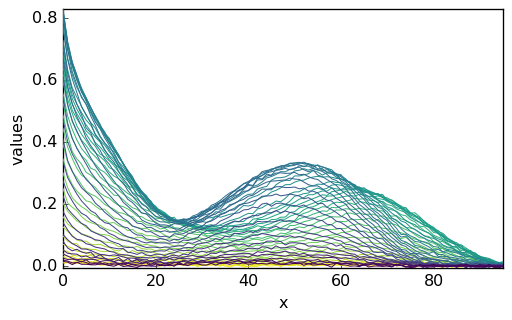

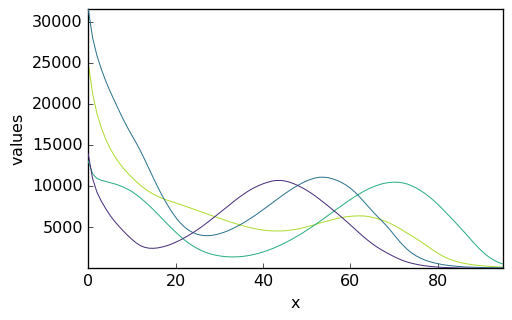

In [5]:
_ = X.plot()
_ = guess.plot()

# Create a MCR-ALS object

We first create a MCR-ALS object named here `mcr`.

The [log_level]{.title-ref} option can be set to `"INFO"` to get verbose
ouput of the MCR-ALS optimization steps.


In [6]:
mcr = scp.MCRALS(log_level="INFO")

# Fit the MCR-ALS model

Then we execute the optimization process using the [fit]{.title-ref}
method with the `X` and `guess` dataset as input arguments.


In [7]:
_ = mcr.fit(X, guess)

 Spectra profile initialized with 4 components


 Initial concentration profile computed


 ***           ALS optimisation log            ***


 #iter     RSE / PCA        RSE / Exp      %change


 -------------------------------------------------


   1        0.000442        0.002807      -97.747926


   2        0.000433        0.002805       -0.048763


 converged !


# Plotting the results

The optimization has converged. We can get the concentration $C$ (C) and
pure spectra profiles $S^T$ (St) and plot them


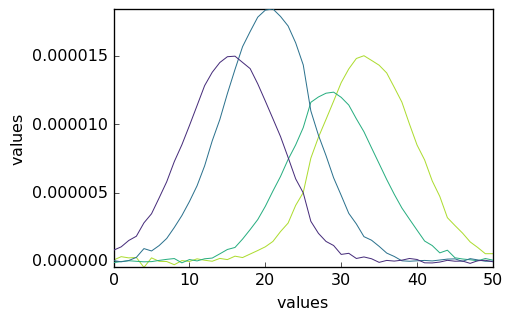

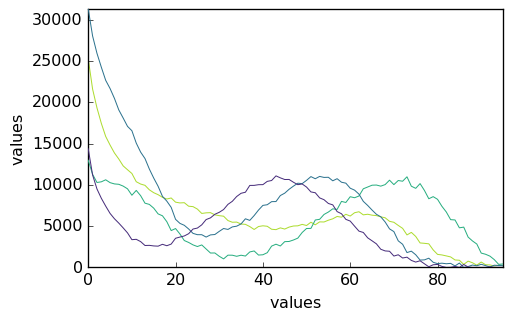

In [8]:
_ = mcr.C.T.plot()
_ = mcr.St.plot()

Finally, plots the reconstructed dataset ($\hat{X} = C.S^T$) *vs.*
original dataset ($X$) as well as the residuals ($E$) for few spectra.

The fit is good and comparable to the original paper (@jaumot:2005).


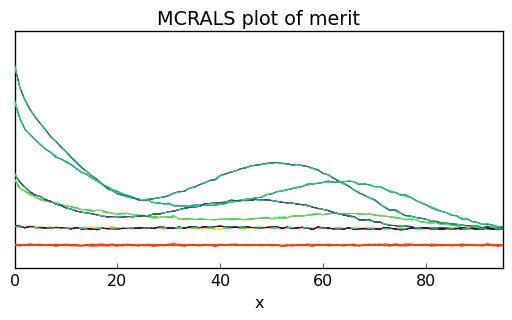

In [9]:
_ = mcr.plotmerit(nb_traces=5)

This ends the example ! The following line can be uncommented if no plot
shows when running the .py script with python


In [10]:
# scp.show()